In [1]:
import pathlib 

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pickle

import morph_analyses as m

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
df = m.preprocessing.load_session_db(dir= pathlib.Path(m.params.repo_dir) / 'data' / 'morph_vr_data')
df = df[df['RewardCount']>40]
df = df.sort_values(['MouseName','DateTime','SessionNumber'])
df = df[df["Track"]=="TwoTower_foraging"]


In [3]:
def single_session_data(filename):
    print(filename)
    vr_data = m.preprocessing.behavior_dataframe(filename)
    trial_info, tstarts_, teleports_ = m.utilities.by_trial_info(vr_data)
    
    effective_morph = trial_info['morphs'] + trial_info['wallJitter']
    return np.hstack((m.unity_transforms.wallmorphx(effective_morph[:, np.newaxis]), effective_morph[:,np.newaxis]))

def single_mouse_data(mouse_alias, df_mouse):


    data = {}
    for i in range(df_mouse.shape[0]):
        sess = df_mouse.iloc[i]
        date, num = sess['DateFolder'],sess['SessionNumber']
        filename = m.params.data_dir / 'morph_vr_data' / mouse_alias / date / f'TwoTower_foraging_{num}.sqlite'
        key = f'date, sess:{num}'
        
        data[key] = single_session_data(filename)
        
    return data

def stack_morphs(data):
    return np.vstack([arr for arr in data.values()])

def single_mouse_priors(metadata, df, x=np.linspace(-.3,1.3,num=1000)[np.newaxis,:]):
    
    alias = metadata['alias']
    test_sessions = metadata['test_sessions']

    mouse_df = df.loc[df["MouseName"]==alias,:]

    morph_dict = {}

    # get datetime of first test session and session
    for first_last, test_sess in zip(('first', 'last'), (test_sessions[0], test_sessions[-1])):
        # print(mouse, alias, test_sess)
        date_time = test_sess['datetime']
        sess_num = test_sess['session']

        # get all behavioral sessions prior
        prev_days_mask = (mouse_df['DateTime']-date_time).apply(lambda x: x.total_seconds()) < 0
        same_day_mask = (mouse_df['DateTime']-date_time).apply(lambda x: x.total_seconds()) == 0
        sess_mask = mouse_df['SessionNumber']<sess_num
        
        include_mask = prev_days_mask + (same_day_mask*sess_mask)
        include_df = mouse_df.loc[include_mask,:]   

        morph_dat = stack_morphs(single_mouse_data(alias,include_df)) 

        sigma_prior=.1

        morph_dict[first_last] = {
            'wallmorph prior': np.mean(m.utilities.gaussian(morph_dat[:,0:1], sigma_prior, x), axis=0),
            'morph prior': np.mean(m.utilities.gaussian(morph_dat[:, 1:], sigma_prior, x), axis=0),                
        }
    return morph_dict


In [4]:
morph_dict= {}
for rf, mice in zip(('rare', 'frequent') , (m.mouse_metadata.rare_mice, m.mouse_metadata.frequent_mice)):
    morph_dict[rf] = {}
    for mouse in mice:
        if rf == 'rare':
            metadata = m.mouse_metadata.rare_sessions[mouse]
        elif rf == 'frequent':
            metadata = m.mouse_metadata.frequent_sessions[mouse]
        else:
            raise Exception("mouse must be in rare or frequent")
        morph_dict[rf][mouse] = single_mouse_priors(metadata, df)


/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/data/morph_vr_data/4139265.3/10_02_2019/TwoTower_foraging_1.sqlite
fix teleports (64126, 21) (60,) (60,)
/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/data/morph_vr_data/4139265.3/10_02_2019/TwoTower_foraging_3.sqlite


/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/src/morph_analyses/preprocessing.py:600: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  ca_df['speed'].iloc[0]=0
/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/src/morph_analyses/preprocessing.py:605: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on w

fix teleports (70611, 21) (60,) (60,)
/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/data/morph_vr_data/4139265.3/11_02_2019/TwoTower_foraging_1.sqlite


/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/src/morph_analyses/preprocessing.py:600: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  ca_df['speed'].iloc[0]=0
/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/src/morph_analyses/preprocessing.py:605: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on w

fix teleports (151977, 21) (147,) (147,)


...

/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/src/morph_analyses/preprocessing.py:600: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  ca_df['speed'].iloc[0]=0
/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/src/morph_analyses/preprocessing.py:605: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on w

fix teleports (124826, 21) (80,) (80,)


/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/src/morph_analyses/preprocessing.py:600: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  ca_df['speed'].iloc[0]=0
/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/src/morph_analyses/preprocessing.py:605: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on w

/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/data/morph_vr_data/4343702.1/21_03_2020/TwoTower_foraging_3.sqlite
fix teleports (53084, 21) (50,) (50,)


/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/src/morph_analyses/preprocessing.py:600: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  ca_df['speed'].iloc[0]=0
/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/src/morph_analyses/preprocessing.py:605: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on w

In [5]:
import pickle
with open(m.params.data_dir / "morph_hists.pkl", 'wb') as file:
    pickle.dump(morph_dict, file)

In [6]:
import pickle
with open(m.params.data_dir / "morph_hists.pkl", 'rb') as file:
    morph_dict = pickle.load(file)

In [7]:
def prior_post(morph_hist_dict,first_last = 'first', sigma_likelihood=.3,x=np.linspace(-.3,1.3,num=1000)[np.newaxis,:]):
    
    mice = [mouse for mouse in morph_hist_dict.keys()]
    
    wallmorph_priors, morph_priors = np.zeros([len(mice),x.shape[1]]),np.zeros([len(mice),x.shape[1]])
    
    for i, (mouse, d) in enumerate(morph_hist_dict.items()):
        wallmorph_priors[i, :] = d[first_last]['wallmorph prior']
        morph_priors[i, :] = d[first_last]['morph prior']
    
    # normalize each mouse to sum to 1
    wallmorph_priors /= wallmorph_priors.sum(axis=-1, keepdims=True)    
    morph_priors /= morph_priors.sum(axis=-1, keepdims=True)
        
    # average across mice
    wallmorph_prior = wallmorph_priors.mean(axis=0, keepdims=True)
    morph_prior = morph_priors.mean(axis=0, keepdims=True)
    # normalize again
    wallmorph_prior /= wallmorph_prior.sum(keepdims=True)
    morph_prior /= morph_prior.sum(keepdims=True)
    
    # calculate posterior
    wallmorph_likelihood = m.utilities.gaussian(x.T, sigma_likelihood, x)
    wallmorph_posterior = wallmorph_prior*wallmorph_likelihood
    wallmorph_posterior /= wallmorph_posterior.sum(axis=1,keepdims=True)
    
    morph_likelihood = m.utilities.gaussian(m.unity_transforms.wallmorphx(x.T), sigma_likelihood, x)
    morph_posterior = morph_prior*morph_likelihood
    morph_posterior /= morph_posterior.sum(axis=1, keepdims=True)
    
    return {
        'each_mouse_wallmorph_prior': wallmorph_priors, 
        'combined_wallmorph_prior': wallmorph_prior,
        'wallmorph_likelihood': wallmorph_likelihood,
        'wallmorph_posterior': wallmorph_posterior,
        'each_mouse_morph_prior': morph_priors,
        'combined_morph_prior': morph_prior,
        'morph_likelihod': morph_likelihood,
        'morph_posterior': morph_posterior,
    }

In [8]:
rare_dists = prior_post(morph_dict['rare'])
freq_dists = prior_post(morph_dict['frequent'])

## Plot priors 

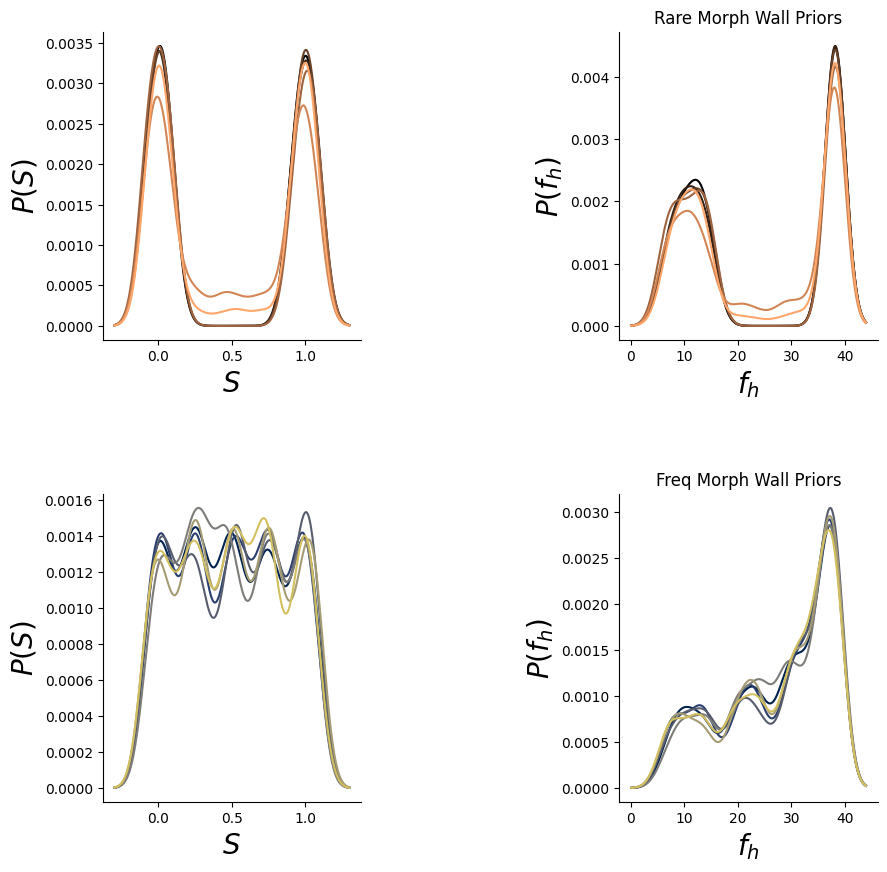

In [9]:
x = np.linspace(-.3,1.3,num=1000)[np.newaxis,:]
f,ax = plt.subplots(2,2,figsize=[10,10])

rare_mice = m.mouse_metadata.rare_mice
for row in range(len(rare_mice)):
    ax[0,0].plot(x.ravel(),rare_dists['each_mouse_morph_prior'][row,:].ravel(),color=plt.cm.copper(float(row)/float(len(rare_mice))))
    ax[0,1].plot(m.unity_transforms.inv_wallmorphx(x.ravel()),rare_dists['each_mouse_wallmorph_prior'][row,:].ravel(),color=plt.cm.copper(float(row)/float(len(rare_mice))))

freq_mice = m.mouse_metadata.frequent_mice
for row in range(len(freq_mice)):
    ax[1,0].plot(x.ravel(),freq_dists['each_mouse_morph_prior'][row,:].ravel(),color=plt.cm.cividis(float(row)/float(len(freq_mice))))
    ax[1,1].plot(m.unity_transforms.inv_wallmorphx(x.ravel()),freq_dists['each_mouse_wallmorph_prior'][row,:].ravel(),color=plt.cm.cividis(float(row)/float(len(freq_mice))))

f.subplots_adjust(hspace=.5)
ax[0,0].set_xlabel("$S$",fontsize=20)
ax[0,0].set_ylabel("$P(S)$",fontsize=20)
ax[0,1].set_xlabel("$f_h$",fontsize=20)
ax[0,1].set_ylabel("$P(f_h)$",fontsize=20)
ax[0,1].set_title('Rare Morph Wall Priors')

ax[1,0].set_xlabel("$S$",fontsize=20)
ax[1,0].set_ylabel("$P(S)$",fontsize=20)
ax[1,1].set_xlabel("$f_h$",fontsize=20)
ax[1,1].set_ylabel("$P(f_h)$",fontsize=20)
ax[1,1].set_title('Freq Morph Wall Priors')
f.subplots_adjust(wspace=1)

ax[0,0].spines['top'].set_visible(False)
ax[0,0].spines['right'].set_visible(False)
ax[0,1].spines['top'].set_visible(False)
ax[0,1].spines['right'].set_visible(False)
ax[1,0].spines['top'].set_visible(False)
ax[1,0].spines['right'].set_visible(False)
ax[1,1].spines['top'].set_visible(False)
ax[1,1].spines['right'].set_visible(False)

## Plot posteriors

Text(0.5, 1.0, '$log(P(f_h|\\hat{f}_h))$')

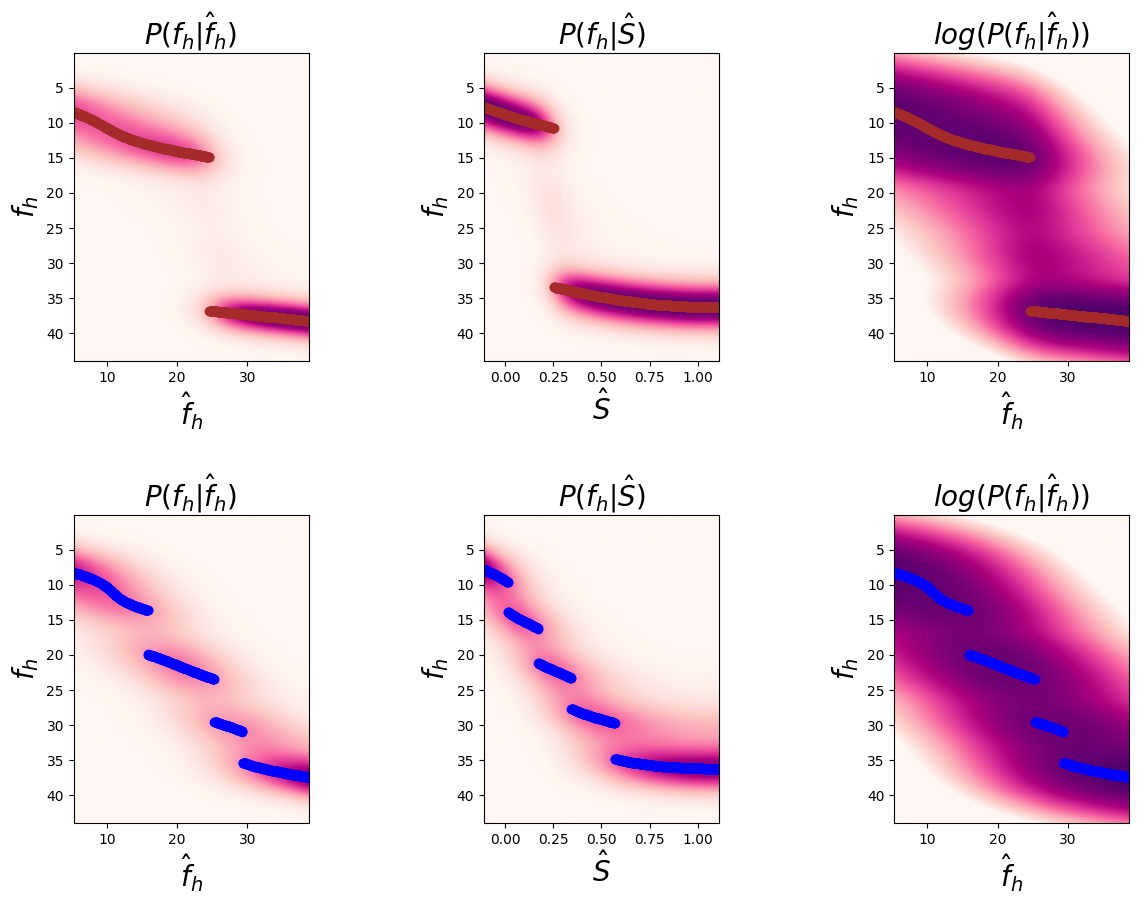

In [ ]:
xx = np.linspace(-.3,1.3,num=1000)
log_rare_post,log_freq_post = np.log(rare_dists['wallmorph_posterior']), np.log(freq_dists['wallmorph_posterior'])


f,ax = plt.subplots(2,3,figsize=[15,10])
f.subplots_adjust(hspace=.5)

rare_yhat_wallmorph = m.unity_transforms.inv_wallmorphx(x[0, np.argmax(rare_dists['wallmorph_posterior'], axis=1)].ravel())
low,high = m.unity_transforms.inv_wallmorphx(-.3),m.unity_transforms.inv_wallmorphx(1.3)
ax[0,0].imshow(rare_dists['wallmorph_posterior'].T,cmap='RdPu',extent=[low,high,high,low],vmin=np.percentile(rare_dists['wallmorph_posterior'],20))
ax[0,0].scatter(m.unity_transforms.inv_wallmorphx(x),rare_yhat_wallmorph,color='brown')
ax[0,0].set_xlim([m.unity_transforms.inv_wallmorphx(-.11),m.unity_transforms.inv_wallmorphx(1.11)])
ax[0,0].set_xlabel("$\hat{f}_{h}$",fontsize=20)
ax[0,0].set_ylabel("$f_{h}$",fontsize=20)
ax[0,0].set_title("$P(f_h|\hat{f}_h)$",fontsize=20)


rare_yhat_morph = m.unity_transforms.inv_wallmorphx(x[0, np.argmax(rare_dists['morph_posterior'], axis=1)].ravel())
ax[0,1].imshow(rare_dists['morph_posterior'].T,cmap='RdPu',extent=[-.3,1.3,high,low],vmin=np.percentile(rare_dists['morph_posterior'],20),aspect=(1.6)/(high-low))
ax[0,1].scatter(xx,rare_yhat_morph,color='brown')

ax[0,1].set_xlim([-.11,1.11])
ax[0,1].set_xlabel("$\hat{S}$",fontsize=20)
ax[0,1].set_ylabel("$f_{h}$",fontsize=20)
ax[0,1].set_title("$P(f_h|\hat{S})$",fontsize=20)

ax[0,2].imshow(log_rare_post.T,cmap='RdPu',extent=[low,high,high,low],vmin=np.percentile(log_rare_post,20))
ax[0,2].scatter(m.unity_transforms.inv_wallmorphx(x),rare_yhat_wallmorph,color='brown')
ax[0,2].set_xlim([m.unity_transforms.inv_wallmorphx(-.11),m.unity_transforms.inv_wallmorphx(1.11)])
ax[0,2].set_xlabel("$\hat{f}_{h}$",fontsize=20)
ax[0,2].set_ylabel("$f_{h}$",fontsize=20)
ax[0,2].set_title("$log(P(f_h|\hat{f}_h))$",fontsize=20)


freq_yhat_wallmorph = m.unity_transforms.inv_wallmorphx(x[0, np.argmax(freq_dists['wallmorph_posterior'], axis=1)].ravel())
low,high = m.unity_transforms.inv_wallmorphx(-.3),m.unity_transforms.inv_wallmorphx(1.3)
ax[1,0].imshow(freq_dists['wallmorph_posterior'].T,cmap='RdPu',extent=[low,high,high,low],vmin=np.percentile(freq_dists['wallmorph_posterior'],20))
ax[1,0].scatter(m.unity_transforms.inv_wallmorphx(x),freq_yhat_wallmorph,color='blue')
ax[1,0].set_xlim([m.unity_transforms.inv_wallmorphx(-.11),m.unity_transforms.inv_wallmorphx(1.11)])
ax[1,0].set_xlabel("$\hat{f}_{h}$",fontsize=20)
ax[1,0].set_ylabel("$f_{h}$",fontsize=20)
ax[1,0].set_title("$P(f_h|\hat{f}_h)$",fontsize=20)


freq_yhat_morph = m.unity_transforms.inv_wallmorphx(x[0, np.argmax(freq_dists['morph_posterior'], axis=1)].ravel())
ax[1,1].imshow(freq_dists['morph_posterior'].T,cmap='RdPu',extent=[-.3,1.3,high,low],vmin=np.percentile(freq_dists['morph_posterior'],20),aspect=(1.6)/(high-low))
ax[1,1].scatter(xx,freq_yhat_morph,color='blue')

ax[1,1].set_xlim([-.11,1.11])
ax[1,1].set_xlabel("$\hat{S}$",fontsize=20)
ax[1,1].set_ylabel("$f_{h}$",fontsize=20)
ax[1,1].set_title("$P(f_h|\hat{S})$",fontsize=20)

ax[1,2].imshow(log_freq_post.T,cmap='RdPu',extent=[low,high,high,low],vmin=np.percentile(log_freq_post,20))
ax[1,2].scatter(m.unity_transforms.inv_wallmorphx(x),freq_yhat_wallmorph,color='blue')
ax[1,2].set_xlim([m.unity_transforms.inv_wallmorphx(-.11),m.unity_transforms.inv_wallmorphx(1.11)])
ax[1,2].set_xlabel("$\hat{f}_{h}$",fontsize=20)
ax[1,2].set_ylabel("$f_{h}$",fontsize=20)
ax[1,2].set_title("$log(P(f_h|\hat{f}_h))$",fontsize=20)
